In [1]:
#!pip install hdbscan
#!pip install umap-learn

#IMPORT LIBRARIES

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler


##Dimension reduction and clustering libraries

from sklearn.cluster import KMeans
import umap
from umap import UMAP
import hdbscan
import sklearn.cluster as cluster
#from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.manifold import trustworthiness
import sklearn.cluster as cluster
#from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import pdist
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV

In [2]:
dF=pd.read_csv("ed_umap_concat.csv")
dF

,UniProt ID,Protein,Length,Sequence,ENSG,Family,Binding mode,Net Charge,Normalized HP Score,A,...,f+,f-,|f+ - f-|,Kappa,umap_1,umap_2,umap_3,umap_4,umap_5,Name
0,Q03164,KMT2A_HUMAN,3291,MAHSCRWRFPARPGTTGGGGGGGRRGLGGAPRQRVPALLLPPGPPV...,ENSG00000118058,CxxC; AT hook,Monomer or homomultimer,75.095126,0.419693,0.058037,...,0.132179,0.109389,0.022789,0.221045,4.331550,8.560451,7.056830,5.474196,1.830177,Histone-lysine N-methyltransferase 2A
1,Q96JG9,ZN469_HUMAN,3681,MPGERPRGAPPPTMTGDLQPRQVASSPGHPSQPPLEDNTPATRTTK...,ENSG00000225614,C2H2 ZF,Monomer or homomultimer,1.929067,0.413450,0.102961,...,0.107579,0.107308,0.000272,0.204999,4.315987,8.548559,7.068495,5.489160,1.840494,Zinc finger protein 469
2,Q15911,ZFHX3_HUMAN,2370,MEGCDSPVVSGKDNGCGIPQHQQWTELNSTHLPDKPSSMEQSTGES...,ENSG00000140836,C2H2 ZF; Homeodomain,Monomer or homomultimer,-53.869706,0.433258,0.078481,...,0.094515,0.117300,0.022785,0.223090,4.378061,8.612233,7.090013,5.454092,1.871549,Zinc finger homeobox protein 3
3,Q96T58,MINT_HUMAN,1906,LSKPAQKSEEANEPKAEKPDATADAEPDANQKAEAAPESQPPASED...,ENSG00000065526,Unknown,Monomer or homomultimer,-5.181961,0.437397,0.111228,...,0.103358,0.106506,0.003148,0.175078,4.378974,8.671642,7.121861,5.397875,1.854507,Msx2-interacting protein
4,Q86UP3,ZFHX4_HUMAN,2430,METCDSPPISRQENGQSTSKLCGTTQLDNEVPEKVAGMEPDRENSS...,ENSG00000091656,C2H2 ZF; Homeodomain,Monomer or homomultimer,-82.743639,0.419259,0.060905,...,0.097119,0.131276,0.034156,0.165641,4.350432,8.568877,7.064519,5.481001,1.849012,Zinc finger homeobox protein 4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1586,Q96ME7,ZN512_HUMAN,470,MSSRLGAVPATSGPTTFKQQRSTRIVGAKNSRTQCSIKDNSFQYTI...,ENSG00000243943,C2H2 ZF; BED ZF,Monomer or homomultimer,39.299810,0.384988,0.051064,...,0.204255,0.119149,0.085106,0.237536,5.937975,9.428108,7.912730,5.824982,2.841476,Zinc finger protein 512
1587,Q9Y2K7,KDM2A_HUMAN,1053,MEPEEERIRYSQRLRGTMRRRYEDDGISDDEIEGKRTFDLEEKLHT...,ENSG00000173120,CxxC,Monomer or homomultimer,1.523930,0.436182,0.043685,...,0.139601,0.137702,0.001899,0.218878,5.824854,9.020073,7.237244,5.621908,2.588345,Lysine-specific demethylase 2A
1588,Q8NHM5,KDM2B_HUMAN,1222,MAGPQMGGSAEDHPPRKRHAAEKQKKKTVIYTKCFEFESATQRPID...,ENSG00000089094,CxxC,Monomer or homomultimer,26.580339,0.417512,0.044190,...,0.157938,0.135843,0.022095,0.207585,5.692550,8.998339,7.282797,5.679488,2.578496,Lysine-specific demethylase 2B
1589,P23025,XPA_HUMAN,248,MAAADGALPEAAALEQPAELPASVRASIERKRQRALMLRQARLAAR...,ENSG00000136936,Unknown,Monomer or homomultimer,1.419742,0.411604,0.108871,...,0.181452,0.173387,0.008065,0.211529,5.863991,9.671505,8.299001,5.550689,2.790794,DNA repair protein complementing XP-A cells


In [3]:
#considering only numeric
numeric_dF = dF.select_dtypes(include='number')
numeric_dF

,Length,Net Charge,Normalized HP Score,A,C,D,E,F,G,H,...,PONDR,f+,f-,|f+ - f-|,Kappa,umap_1,umap_2,umap_3,umap_4,umap_5
0,3291,75.095126,0.419693,0.058037,0.017624,0.044060,0.065330,0.026740,0.063507,0.021878,...,0.811623,0.132179,0.109389,0.022789,0.221045,4.331550,8.560451,7.056830,5.474196,1.830177
1,3681,1.929067,0.413450,0.102961,0.017930,0.042651,0.064656,0.025537,0.107579,0.024993,...,0.928091,0.107579,0.107308,0.000272,0.204999,4.315987,8.548559,7.068495,5.489160,1.840494
2,2370,-53.869706,0.433258,0.078481,0.022363,0.042194,0.075105,0.032911,0.067932,0.027426,...,0.598446,0.094515,0.117300,0.022785,0.223090,4.378061,8.612233,7.090013,5.454092,1.871549
3,1906,-5.181961,0.437397,0.111228,0.003673,0.033054,0.073452,0.007870,0.048793,0.022560,...,0.868624,0.103358,0.106506,0.003148,0.175078,4.378974,8.671642,7.121861,5.397875,1.854507
4,2430,-82.743639,0.419259,0.060905,0.019753,0.060082,0.071193,0.031687,0.048971,0.027572,...,0.720360,0.097119,0.131276,0.034156,0.165641,4.350432,8.568877,7.064519,5.481001,1.849012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1586,470,39.299810,0.384988,0.051064,0.021277,0.031915,0.087234,0.027660,0.059574,0.021277,...,0.474481,0.204255,0.119149,0.085106,0.237536,5.937975,9.428108,7.912730,5.824982,2.841476
1587,1053,1.523930,0.436182,0.043685,0.024691,0.063628,0.074074,0.023742,0.056030,0.025641,...,0.441849,0.139601,0.137702,0.001899,0.218878,5.824854,9.020073,7.237244,5.621908,2.588345
1588,1222,26.580339,0.417512,0.044190,0.022095,0.053191,0.082651,0.027823,0.053191,0.025368,...,0.503463,0.157938,0.135843,0.022095,0.207585,5.692550,8.998339,7.282797,5.679488,2.578496
1589,248,1.419742,0.411604,0.108871,0.012097,0.048387,0.125000,0.016129,0.048387,0.028226,...,0.364898,0.181452,0.173387,0.008065,0.211529,5.863991,9.671505,8.299001,5.550689,2.790794


In [5]:
#preprocessing 
#dF=pd.read_csv("full_umap_concat.pkl")

#considering only numeric
numeric_dF = dF.select_dtypes(include='number')

#new column add
#dF['Numbering'] = range(1, len(dF) + 1)

#EXCLUDE no needed columns
columns_to_exclude = ['Net Charge','f+','|f+ - f-|','f-','Normalized HP Score','PONDR','umap_1','umap_2','umap_3','umap_4','umap_5']
df = numeric_dF.drop(columns=columns_to_exclude)

df

,Length,A,C,D,E,F,G,H,I,K,...,N,P,Q,R,S,T,V,W,Y,Kappa
0,3291,0.058037,0.017624,0.044060,0.065330,0.026740,0.063507,0.021878,0.037071,0.074142,...,0.036159,0.090854,0.044060,0.058037,0.143421,0.065330,0.052871,0.003039,0.011547,0.221045
1,3681,0.102961,0.017930,0.042651,0.064656,0.025537,0.107579,0.024993,0.006248,0.040750,...,0.014398,0.154034,0.046455,0.066830,0.101331,0.052431,0.030155,0.006792,0.007063,0.204999
2,2370,0.078481,0.022363,0.042194,0.075105,0.032911,0.067932,0.027426,0.025738,0.057384,...,0.042194,0.089451,0.062869,0.037131,0.101266,0.052743,0.039241,0.004641,0.023207,0.223090
3,1906,0.111228,0.003673,0.033054,0.073452,0.007870,0.048793,0.022560,0.031480,0.058762,...,0.028856,0.135362,0.055089,0.044596,0.100210,0.075551,0.084470,0.001574,0.009444,0.175078
4,2430,0.060905,0.019753,0.060082,0.071193,0.031687,0.048971,0.027572,0.029630,0.069959,...,0.047737,0.087654,0.068724,0.027160,0.107819,0.060494,0.045267,0.002881,0.022634,0.165641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1586,470,0.051064,0.021277,0.031915,0.087234,0.027660,0.059574,0.021277,0.031915,0.110638,...,0.023404,0.065957,0.059574,0.093617,0.093617,0.048936,0.051064,0.010638,0.023404,0.237536
1587,1053,0.043685,0.024691,0.063628,0.074074,0.023742,0.056030,0.025641,0.046534,0.059829,...,0.035138,0.058879,0.036087,0.079772,0.078822,0.059829,0.056030,0.018993,0.026591,0.218878
1588,1222,0.044190,0.022095,0.053191,0.082651,0.027823,0.053191,0.025368,0.036007,0.080196,...,0.030278,0.076923,0.042553,0.077741,0.083470,0.048282,0.058101,0.017185,0.023732,0.207585
1589,248,0.108871,0.012097,0.048387,0.125000,0.016129,0.048387,0.028226,0.040323,0.112903,...,0.016129,0.044355,0.048387,0.068548,0.032258,0.036290,0.056452,0.012097,0.028226,0.211529


In [6]:
L_min, L_max =df['Length'].min(), df['Length'].max()
L_min, L_max

(22, 3681)

In [23]:
df['Length']= (df['Length']- L_min)/(L_max - L_min)
df

,Length,A,C,D,E,F,G,H,I,K,...,N,P,Q,R,S,T,V,W,Y,Kappa
0,0.113280,0.06576,0.01741,0.05609,0.09671,0.01934,0.12766,0.02708,0.02901,0.05416,...,0.02708,0.05029,0.03095,0.05222,0.15280,0.03868,0.04255,0.00967,0.00967,0.38993
1,0.392242,0.10480,0.01871,0.04304,0.04554,0.03369,0.10106,0.01934,0.00873,0.04554,...,0.01747,0.13911,0.03930,0.06488,0.10917,0.04367,0.03868,0.00561,0.02308,0.22850
2,0.198305,0.04835,0.02123,0.05071,0.05542,0.05189,0.04953,0.02948,0.04481,0.04717,...,0.06486,0.06840,0.08255,0.04127,0.08019,0.06250,0.04127,0.00590,0.03184,0.19898
3,0.120473,0.11743,0.03303,0.04954,0.05872,0.02569,0.08807,0.02752,0.02018,0.04404,...,0.00917,0.11743,0.04771,0.06606,0.07523,0.04037,0.05138,0.00917,0.00734,0.18148
4,0.350116,0.09937,0.00973,0.03822,0.08687,0.01876,0.07644,0.02988,0.01876,0.03405,...,0.01181,0.12370,0.05629,0.07158,0.10980,0.05629,0.03475,0.01390,0.01390,0.21583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1648,0.148472,0.09021,0.00306,0.04587,0.05963,0.02446,0.13303,0.03670,0.01070,0.03517,...,0.02446,0.09174,0.03211,0.05046,0.14373,0.04281,0.03670,0.00459,0.02141,0.17784
1649,0.099409,0.06695,0.01728,0.03888,0.06479,0.01728,0.06263,0.02592,0.03672,0.05184,...,0.03024,0.13607,0.04968,0.05184,0.08855,0.07127,0.06695,0.00864,0.00648,0.19948
1650,0.033650,0.02899,0.05314,0.05314,0.08213,0.03382,0.05314,0.02899,0.04348,0.06763,...,0.08213,0.02899,0.05314,0.05314,0.07729,0.03865,0.05314,0.00966,0.02899,0.21129
1651,0.032623,0.09406,0.02475,0.01485,0.05446,0.01485,0.12871,0.00990,0.00495,0.06436,...,0.00990,0.20297,0.04455,0.04455,0.09901,0.06436,0.04455,0.00495,0.00000,0.34279


In [18]:
families = {1: 'ZF C2H2-type',2: 'bHLH',3: 'bZIP',4: 'Fork-head',5: 'Nuclear receptor',
    6: 'HMG box',7: 'ETS',8: 'T-box',9: 'A.T. hooks',10: 'POU',11: 'Myb-like',12: 'ZF THAP-type',
    13: 'HTH CENPB-type',14: 'E2F',15: 'E2F', 16: 'ZF Bed-type',17: 'ZF GATA-type',
    18: 'RHD',19: 'SMAD',20: 'Others',21: 'SAND',22: 'CxxC',23: 'IRF tryptophan pentad repeat',
    24: 'RFX-type',25: 'HSF',26: 'MBD',27: 'DM',28: 'CUT',29: 'Unassigned',30: 'Others',
    31: 'STAT',32: 'ARID',33: 'MADS-box/Mef2-type', 34: 'Grainyhead',35: 'DACHbox-N',36: 'NBD',
    37: 'MYND-type',38: 'CSD',39: 'Runt',40: 'GCM',41: 'IPT/TIG',42: 'Paired/Homeobox/PAI/RED',
    43: 'H-S-H (helix-span-helix) dimerization',44: 'TEA',45: 'GTF2I-like',46: 'NDT80',
    47: 'Prospero',48: 'FLYWCH-type 1'}
dF['Family'] = dF['Label'].replace(families)


KeyError: 'Label'

In [19]:
family_label=np.array(dF.Family)
#family_label=family_label.astype(str)
family_label

array(['C2H2 ZF', 'AT hook', 'bHLH', ..., 'C2H2 ZF', 'C2H2 ZF',
       'Homeodomain; POU'], dtype=object)

In [7]:
df_scaled= StandardScaler().fit_transform(df)
df_scaled

array([[ 8.51103594e+00, -4.61751566e-01, -4.10315109e-01, ...,
        -7.80972616e-01, -8.64468232e-01,  4.52289197e-01],
       [ 9.65658662e+00,  5.80909678e-01, -3.92165085e-01, ...,
        -2.59470204e-01, -1.19534251e+00,  1.55768798e-01],
       [ 5.80577395e+00,  1.27401842e-02, -1.29304860e-01, ...,
        -5.58261777e-01, -3.94318472e-03,  4.90079595e-01],
       ...,
       [ 2.43374272e+00, -7.83137276e-01, -1.45193010e-01, ...,
         1.18472769e+00,  3.47901557e-02,  2.03554776e-01],
       [-4.27196672e-01,  7.18072995e-01, -7.38051328e-01, ...,
         4.77703435e-01,  3.66466989e-01,  2.76438331e-01],
       [ 2.54259117e-01, -3.09816700e-01,  1.88009318e+00, ...,
         1.11271087e+00,  1.28399976e-01, -8.45101538e-01]])

# UMAP MODELLING

In [ ]:
umaP=umap.UMAP()
u=umaP.fit_transform(df_scaled)

In [ ]:
u.shape

In [ ]:
color=dF['Label']

#generalized PLOT UMAP RESULTS without hyper parameters

plt.scatter(u[:,0],u[:,1],c=color,cmap='viridis')
plt.colorbar(label='Label')
plt.title('UMAP embedding with random colors')
plt.show()


In [ ]:
print(u)

### Here , we consider umap HyperParameters from previous examination as n_neighbours=50,min_dist=0.0,metric=euclidean

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


n_components=2, Trustworthiness=0.8627155595822011
n_components=3, Trustworthiness=0.884953291164151
n_components=4, Trustworthiness=0.8917339845273676
n_components=5, Trustworthiness=0.8939931290347531
n_components=6, Trustworthiness=0.895016885022793
n_components=7, Trustworthiness=0.8950274774325475
n_components=8, Trustworthiness=0.895250963177275
n_components=9, Trustworthiness=0.8959764312661891
n_components=10, Trustworthiness=0.8960984223157272


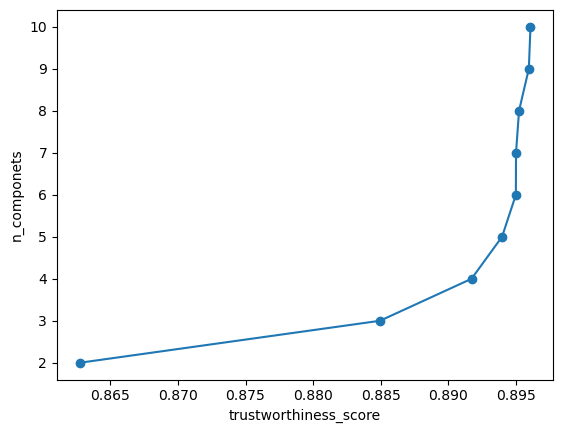

In [8]:
#calculate trustworthiness of UMAP components 

n_components_range = [2,3,4,5,6,7,8,9,10]
trustworthiness_scores = []
for n_components in n_components_range:
    umap_model = umap.UMAP(n_components=n_components,min_dist=0.0,n_neighbors=50,metric='euclidean',random_state=42)
    embeddings = umap_model.fit_transform(df_scaled)

    # Evaluate trustworthiness
    trustworthiness_score = trustworthiness(df_scaled, embeddings, n_neighbors=50)
    trustworthiness_scores.append(trustworthiness_score)

    print(f'n_components={n_components}, Trustworthiness={trustworthiness_score}')
#plot the relation
plt.plot(trustworthiness_scores,n_components_range,marker='o')
plt.xlabel("trustworthiness_score")
plt.ylabel("n_componets")
plt.show()

#### HDBSCAN clustering UMAP components 

suitable min_samples and min_cluster for hdbscan w.r.t noise percentage

In [ ]:
#noise-level
# UMAP with 3 components
umap_model = umap.UMAP(n_components=4,min_dist=0.0,n_neighbors=50,metric='euclidean',random_state=42)
umap_embeddings = umap_model.fit_transform(df_scaled)

# Varying parameters for HDBSCAN
min_cluster_sizes = [5, 10, 12, 15, 17, 20, 25, 30, 35, 40, 45, 50]
min_samples_values = [1, 3, 5, 6, 7, 9, 10, 13, 15, 17, 20, 23, 25, 27, 32]

# Initialize arrays to store noise levels
noise_levels = np.zeros((len(min_cluster_sizes), len(min_samples_values)))

# Loop through parameter combinations
for i, min_cluster_size in enumerate(min_cluster_sizes):
    for j, min_samples in enumerate(min_samples_values):
        hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        hdbscan_labels = hdbscan_clusterer.fit_predict(umap_embeddings)
        
        # Count the number of points labeled as noise (-1)
        noise_levels[i, j] = np.sum(hdbscan_labels == -1)

# Plot the noise levels
fig, ax = plt.subplots()
c = ax.pcolormesh(min_samples_values, min_cluster_sizes, noise_levels, cmap='viridis', shading='auto')
fig.colorbar(c, label='Noise Level')
ax.set_xlabel('Min Samples')
ax.set_ylabel('Min Cluster Size')
ax.set_title('Noise Level vs. Parameter Tuning in HDBSCAN')
plt.show()

In [ ]:
#noise percentage - through calculation

#DataFrame to store results
results = pd.DataFrame(columns=['min_cluster_size', 'min_samples', 'noise_percentage'])


# Parameter tuning
min_cluster_sizes = [5, 10, 12, 15, 17, 20, 25, 30, 35, 40, 45, 50]
min_samples_values = [1, 3, 5, 6, 7, 9, 10, 13, 15, 17, 20, 23, 25, 27, 32]

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_values:
        # HDBSCAN with parameter tuning
        hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        hdbscan_labels = hdbscan_clusterer.fit_predict(umap_embeddings)

        # Calculate noise level (percentage of points labeled as noise)
        noise_percentage = np.sum(hdbscan_labels == -1) / len(hdbscan_labels)

        # Append results to the DataFrame
        results = pd.concat([results, pd.DataFrame({'min_cluster_size': [min_cluster_size],
                                                     'min_samples': [min_samples],
                                                     'noise_percentage': [noise_percentage]})], ignore_index=True)

# Convert 'noise_percentage' to numeric
results['noise_percentage'] = pd.to_numeric(results['noise_percentage'])

# Reshape the DataFrame for the correlation matrix
corr_data = results.pivot_table(index='min_cluster_size', columns='min_samples', values='noise_percentage', aggfunc='mean')

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Noise Percentage vs. Parameter Tuning in HDBSCAN')
plt.xlabel('Min Samples')
plt.ylabel('Min Cluster Size')
plt.show()


In [ ]:
#dbcv score- heatmap
def calculate_dbcv(umap_embeddings, hdbscan_labels):
    distances = pairwise_distances(umap_embeddings, metric='euclidean')
    mean_intra_cluster_distances = []

    for cluster_label in np.unique(hdbscan_labels):
        cluster_indices = np.where(hdbscan_labels == cluster_label)[0]
        if len(cluster_indices) > 1:
            cluster_distances = distances[cluster_indices][:, cluster_indices]
            mean_intra_cluster_distances.append(np.mean(cluster_distances[np.triu_indices(len(cluster_distances), k=1)]))

    return np.mean(mean_intra_cluster_distances)

# DataFrame to store results
results = pd.DataFrame(columns=['min_cluster_size', 'min_samples', 'dbcv_score'])

# Parameter tuning
min_cluster_sizes = [5, 10, 12, 15, 17, 20, 25, 30, 35, 40, 45, 50]
min_samples_values = [1, 3, 5, 6, 7, 9, 10, 13, 15, 17, 20, 23, 25, 27, 32]

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_values:
        # HDBSCAN with parameter tuning
        hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        hdbscan_labels = hdbscan_clusterer.fit_predict(umap_embeddings)

        # Calculate DBCV Score
        dbcv_score = calculate_dbcv(umap_embeddings, hdbscan_labels)

        # Append results to the DataFrame
        results = pd.concat([results, pd.DataFrame({'min_cluster_size': [min_cluster_size],
                                                     'min_samples': [min_samples],
                                                     'dbcv_score': [dbcv_score]})], ignore_index=True)

# Reshape the DataFrame for the correlation matrix
corr_data = results.pivot_table(index='min_cluster_size', columns='min_samples', values='dbcv_score', aggfunc='mean')

# Plotting the correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".4f")
plt.title('DBCV Score vs. Parameter Tuning in HDBSCAN')
plt.xlabel('Min Samples')
plt.ylabel('Min Cluster Size')
plt.show()


### my DBCV code

float32


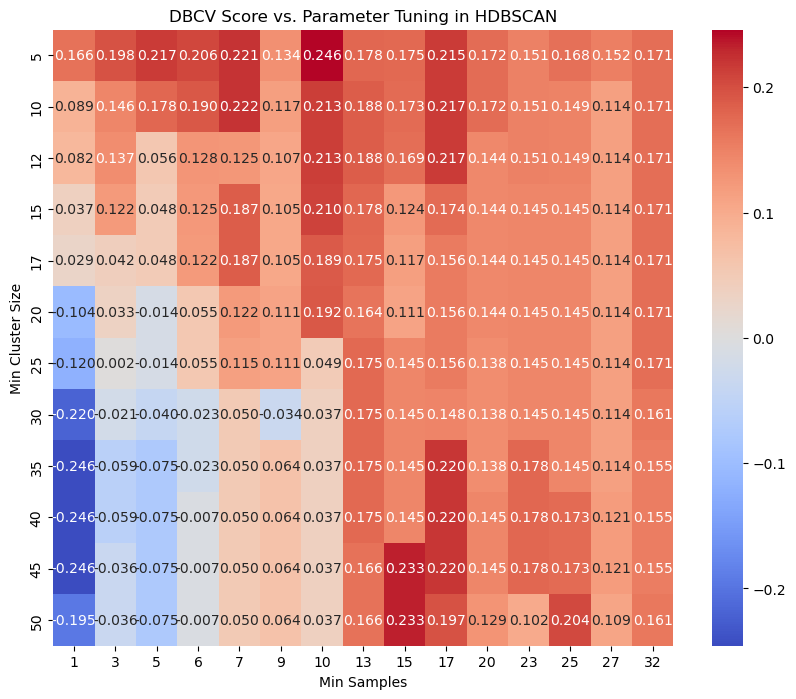

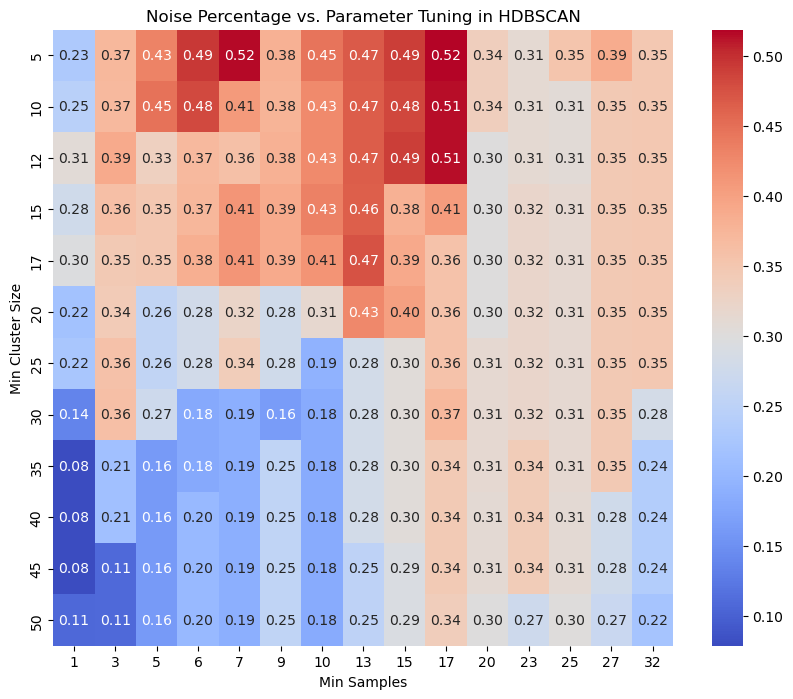

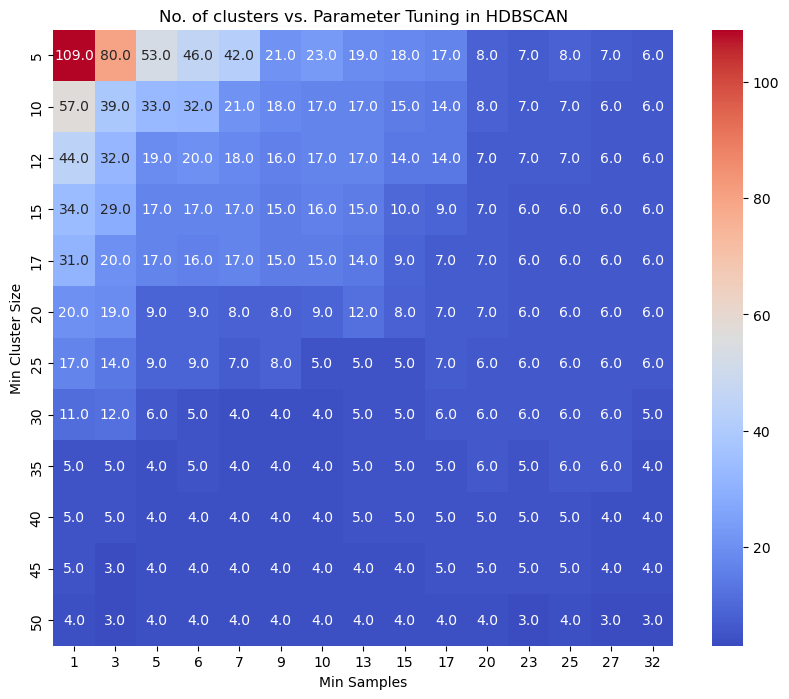

In [9]:
from hdbscan import validity

# UMAP with 3 components
umap_model = umap.UMAP(n_components=5,min_dist=0.0,n_neighbors=50,metric='euclidean',random_state=42)
umap_embeddings = umap_model.fit_transform(df_scaled)

# DataFrame to store results
results = pd.DataFrame(columns=['min_cluster_size', 'min_samples', 'dbcv_score','noise_percentage','n_clusters'])

# Parameter tuning
min_cluster_sizes = [5, 10, 12, 15, 17, 20, 25, 30, 35, 40, 45, 50]
min_samples_values = [1, 3, 5, 6, 7, 9, 10, 13, 15, 17, 20, 23, 25, 27, 32]

print(umap_embeddings.dtype)
umap_embeddings = umap_embeddings.astype(np.double)   # needed to calculate the DBCV score, otherwise giving error with float values

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_values:
        # HDBSCAN with parameter tuning
        hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        hdbscan_labels = hdbscan_clusterer.fit_predict(umap_embeddings)

        # Calculate DBCV Score
        #dbcv_score = hdbscan.validity.relative_validity(hdbscan_clusterer)
        dbcv_score = hdbscan.validity.validity_index(umap_embeddings, hdbscan_labels)
        
        # Calculate noise level (percentage of points labeled as noise)
        noise_percentage = np.sum(hdbscan_labels == -1) / len(hdbscan_labels)
        
        # Calculate no. of clusters
        n_clusters=len(np.unique(hdbscan_labels))-1
                
        # Append results to the DataFrame
        results = pd.concat([results, pd.DataFrame({'min_cluster_size': [min_cluster_size],
                                                     'min_samples': [min_samples],
                                                    'noise_percentage': [noise_percentage],
                                                    'n_clusters': [n_clusters],
                                                     'dbcv_score': [dbcv_score]})], ignore_index=True)

# Reshape the DataFrame for the correlation matrix
corr_data1 = results.pivot_table(index='min_cluster_size', columns='min_samples', values='dbcv_score', aggfunc='mean')
corr_data2 = results.pivot_table(index='min_cluster_size', columns='min_samples', values='noise_percentage', aggfunc='mean')
corr_data3 = results.pivot_table(index='min_cluster_size', columns='min_samples', values='n_clusters', aggfunc='mean')

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data1, annot=True, cmap='coolwarm', fmt=".3f")
plt.title('DBCV Score vs. Parameter Tuning in HDBSCAN')
plt.xlabel('Min Samples')
plt.ylabel('Min Cluster Size')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data2, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Noise Percentage vs. Parameter Tuning in HDBSCAN')
plt.xlabel('Min Samples')
plt.ylabel('Min Cluster Size')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data3, annot=True, cmap='coolwarm', fmt=".1f")
plt.title('No. of clusters vs. Parameter Tuning in HDBSCAN')
plt.xlabel('Min Samples')
plt.ylabel('Min Cluster Size')
plt.show()

In [ ]:
# UMAP with 6 components
umap_model = umap.UMAP(n_components=6,min_dist=0.0,n_neighbors=50,metric='euclidean',random_state=42)
umap_embeddings = umap_model.fit_transform(df_scaled)

#dbcv according to randomsearch
hdb = hdbscan.HDBSCAN(gen_min_span_tree=True).fit(umap_embeddings)

param_dist = {
    'min_samples': [1, 3, 5, 6, 7, 9, 10, 13, 15, 17, 20, 23, 25, 27, 32],
    'min_cluster_size': [10, 12, 15, 17, 20, 25, 30, 35, 40, 45, 50],
    'cluster_selection_epsilon': [0.1, 0.2, 0.3, 0.4],
    'cluster_selection_method': ['eom', 'leaf'],
    'metric': ['euclidean', 'manhattan']
}

validity_scorer = make_scorer(hdbscan.validity.validity_index, greater_is_better=True)

n_iter_search = 100
random_search = RandomizedSearchCV(
    hdb, param_distributions=param_dist, n_iter=n_iter_search, scoring=validity_scorer, random_state=42
)

random_search.fit(umap_embeddings)



In [ ]:
print(f"Best Parameters {random_search.best_params_}")
print(f"DBCV score: {random_search.best_estimator_.relative_validity_}")

In [6]:
family_label

array(['ZF C2H2-type', 'ZF C2H2-type', 'ZF C2H2-type', ...,
       'ZF C2H2-type', 'Paired/Homeobox/PAI/RED',
       'Paired/Homeobox/PAI/RED'], dtype=object)

In [7]:
umap_model = umap.UMAP(n_components=2,min_dist=0.0,n_neighbors=50,metric='euclidean',random_state=42)
umap_embeddings = umap_model.fit_transform(df_scaled)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [19]:
len(umap_embeddings[:,0])

1264

In [8]:
dF['umap_1']=(umap_embeddings[:,0])
dF['umap_2']=(umap_embeddings[:,1])
dF

,Protein,UniProtID,Label,Full Sequence,Normalized HP Score,PONDR Score,A,C,D,E,...,V,W,Y,f+,f-,|f+ - f-|,Kappa,Family,umap_1,umap_2
0,ANKZ1_HUMAN,Q9H8Y5,1.0,MSPAPDAAPAPASISLFDLSADAPVFQGLSLVSHAPGEALARAPRT...,0.414279,0.450560,0.107438,0.016529,0.050964,0.086777,...,0.038567,0.008264,0.016529,0.147383,0.137741,0.009642,0.179070,ZF C2H2-type,8.669570,3.759782
1,ANM3_HUMAN,O60678,1.0,MCSLASGATGGRGAVENEEDLPELSDSGDEAAWEDEDDADLPHGKQ...,0.470956,0.164330,0.060264,0.022599,0.071563,0.079096,...,0.075330,0.009416,0.039548,0.105461,0.150659,0.045198,0.216708,ZF C2H2-type,10.479420,6.875522
2,CHAP1_HUMAN,Q96JM3,1.0,MEAFQELRKPSARLECDHCSFRGTDYENVQIHMGTIHPEFCDEMDA...,0.406924,0.731708,0.065271,0.020936,0.034483,0.084975,...,0.039409,0.018473,0.012315,0.133005,0.119458,0.013547,0.181992,ZF C2H2-type,10.111715,4.797624
3,DZIP1_HUMAN,Q86YF9,1.0,MQAEAADWFSSMPFQKHVYYPLASGPEGPDVAVAAAAAGAASMACA...,0.416558,0.499426,0.065744,0.013841,0.047290,0.113033,...,0.048443,0.009227,0.012687,0.136101,0.160323,0.024221,0.174885,ZF C2H2-type,9.828274,6.289014
4,LMBL1_HUMAN,Q9Y468,1.0,MHLVAGDSPGSGPHLPATAFIIPASSATLGLPSSALDVSCFPREPI...,0.433108,0.487211,0.072619,0.028571,0.055952,0.072619,...,0.057143,0.021429,0.022619,0.092857,0.128571,0.035714,0.229229,ZF C2H2-type,9.476432,4.593238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1259,GTD2A_HUMAN,Q86UP8,45.0,MAQVAVSTLPVEEESSSETRMVVTFLVSALESMCKELAKSKAEVAC...,0.471970,0.250903,0.050580,0.025290,0.045311,0.088514,...,0.081138,0.010537,0.033720,0.110643,0.133825,0.023182,0.178539,GTF2I-like,10.466311,6.802938
1260,GTD2B_HUMAN,Q6EKJ0,45.0,MAQVAVSTLPVEEESSSETRMVVTFLVSALESMCKELAKSKAEVAC...,0.472322,0.254399,0.049526,0.025290,0.044257,0.088514,...,0.082192,0.010537,0.033720,0.112750,0.132771,0.020021,0.179270,GTF2I-like,10.487171,6.868007
1261,MBNL2_HUMAN,Q5VZF2,1.0,MALNVAPVRDTKWLTLEVCRQFQRGTCSRSDEECKFAHPPKSCQVE...,0.476884,0.525462,0.112601,0.048257,0.026810,0.042895,...,0.061662,0.002681,0.021448,0.093834,0.069705,0.024129,0.139479,ZF C2H2-type,12.068195,5.843113
1262,COE2_HUMAN,Q9HAK2,42.0,MFGIQDTLGRGPTLKEKSLGAEMDSVRSWVRNVGVVDANVAAQSGV...,0.460966,0.391281,0.059130,0.017391,0.036522,0.041739,...,0.076522,0.005217,0.027826,0.100870,0.078261,0.022609,0.164988,Paired/Homeobox/PAI/RED,11.456235,6.186460


UMAP components - HDBSCAN clustering with resulting HyperParameters

In [28]:
import plotly.express as px
#hdbscan for two umap components 
#cluster the data using hdbscan
labels = hdbscan.HDBSCAN(
    min_samples=15,
    min_cluster_size=40,
    #metric='euclidean',
    #cluster_selection_epsilon=0.4,
    #cluster_selection_method='eom'
).fit_predict(umap_embeddings)
#visualize the results
clustered = (labels >= 0)
''''
plt.scatter(umap_embeddings[~clustered, 0],
            umap_embeddings[~clustered, 1],
            color=(0.5, 0.5, 0.5),
            s=1,
            alpha=0.5)


plt.scatter(umap_embeddings[clustered, 0],
            umap_embeddings[clustered, 1],
            #c=labels[clustered],
            c= family_label[clustered],
            s=1,
            #cmap='Spectral'
           );
plt.colorbar(scatter, label='label')
'''
fig = px.scatter(x=umap_embeddings[clustered, 0], y=umap_embeddings[clustered, 1], 
                    color=family_label[clustered],
                   size_max=2)
fig.update_layout(coloraxis_colorbar=dict(title='Family'))
fig.show()

fig = px.scatter(x=umap_embeddings[clustered, 0], y=umap_embeddings[clustered, 1], 
                    color=labels[clustered],
                   size_max=2)
fig.update_layout(coloraxis_colorbar=dict(title='Cluster'))
fig.show()

print(np.unique(labels))
num_noise_points = np.sum(labels == -1)

print(f"Number of Noise Points: {num_noise_points}")

[-1  0  1  2]
Number of Noise Points: 62


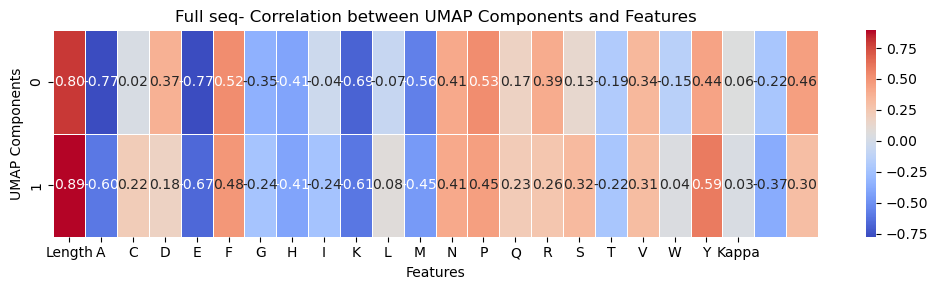

In [29]:
# Calculation,sing the Pearson correlation coefficient
correlation_matrix = np.corrcoef(np.concatenate((umap_embeddings.T, df.values.T)))
 
# Extraction of correlations between UMAP components and features
umap_feature_correlations = correlation_matrix[:2, 2:]
 
# Visualization 
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 2)
sns.heatmap(umap_feature_correlations, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title('Full seq- Correlation between UMAP Components and Features')
plt.xlabel('Features')
plt.ylabel('UMAP Components')
plt.xticks(ticks=np.arange(len(df.columns)) + 0.5, labels=df.columns)
plt.tight_layout()
plt.show()

### Coloring wrt physical features

In [11]:
color_scale = "Rainbow"
size = 10
for feature in columns_to_exclude:
        
        # Plot and save 2D UMAP plot with labels
        fig_umap_2d = px.scatter(dF, x="umap_1", y="umap_2", size_max=size, color=feature,
                                 title=f"Full Sequence 2D UMAP {feature} scale", color_continuous_scale=color_scale,
                                 hover_name="Protein",hover_data=['UniProtID','Family'])
        fig_umap_2d.write_html(f"Full sequence_umap_2d_{feature}.html")

### Sunburst plot

In [35]:
import plotly.express as px
 
#df2=df.drop('Normalized HP Score', axis=1)  # the total value of this is always highest
df2=df

#DataFrame with features and HDBSCAN labels
df_hdbscan = pd.concat([df2, pd.Series(labels, name='HDBSCAN_Labels')], axis=1)
 
# Melt the DataFrame to have a column for features, values, and HDBSCAN labels
df_melted = pd.melt(df_hdbscan, id_vars=['HDBSCAN_Labels'], value_vars=df2.columns)
 
# Create a sunburst plot
fig = px.sunburst(df_melted, path=['HDBSCAN_Labels', 'variable'], values='value',
                  title='Full seq- Sunburst Plot of Features by Cluster in HDBSCAN')
 
fig.show()

### generate or update the pkl file to store custer labels for different clusterings

In [48]:
#df_labels=pd.DataFrame()
df_labels= pd.read_pickle('../full_seq_cluster_labels.pkl')
#df_labels['UniProtID']= dF['UniProtID']
df_labels= pd.concat([df_labels, pd.Series(labels, name='3_CLabels_fractions_kappa')], axis=1)
df_labels.to_pickle('../full_seq_cluster_labels.pkl')
df_labels

,UniProtID,102_CLabels_fractions_kappa,3_CLabels_fractions_kappa
0,Q9H8Y5,72,0
1,O60678,87,0
2,Q96JM3,38,0
3,Q86YF9,67,0
4,Q9Y468,37,0
...,...,...,...
1259,Q86UP8,87,0
1260,Q6EKJ0,87,0
1261,Q5VZF2,59,0
1262,Q9HAK2,101,0


In [30]:
from sklearn.feature_selection import mutual_info_classif

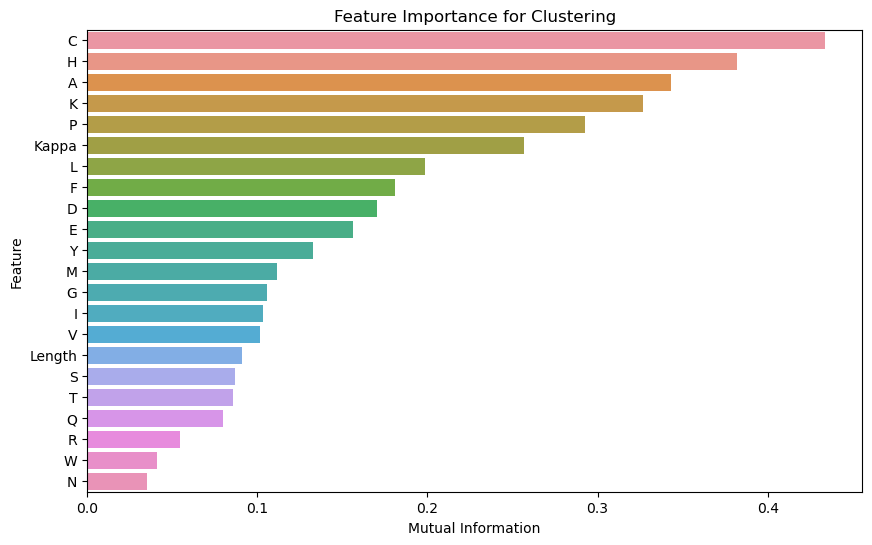

In [31]:
# Compute mutual information between features and cluster labels
mi = mutual_info_classif(df.values, labels)

# Create a DataFrame to store feature importance scores
feature_importance_df  = pd.DataFrame({'Feature': df.columns, 'Mutual_Information': mi})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Mutual_Information', ascending=False)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Mutual_Information', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for Clustering')
plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.show()

### checking the effect of changing the cluster label values on MI

In [36]:
(np.unique(labels))

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101])

In [37]:
changed_labels= labels

for i in np.unique(labels):
    if i%2==0:
        changed_labels[changed_labels == i] = i*100
    if i%2!=0:
        changed_labels[changed_labels == i] = i*10000

In [39]:
len(np.unique(changed_labels))

102

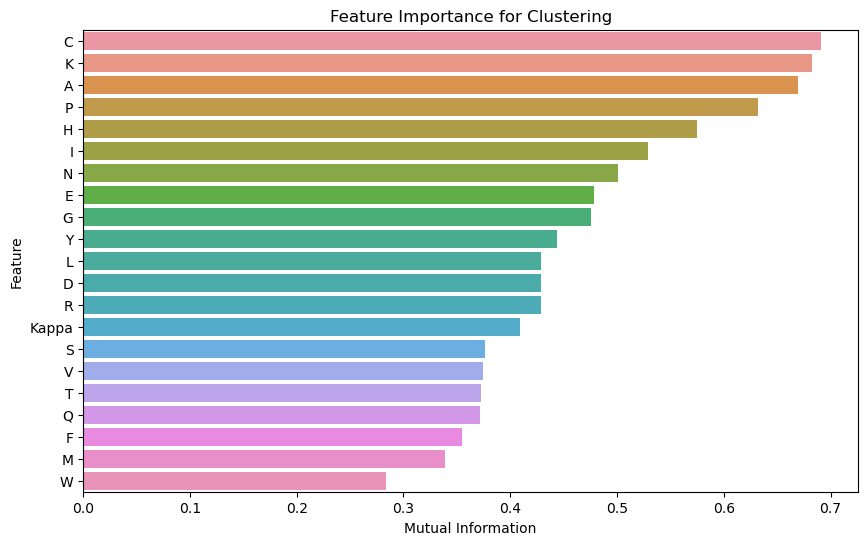

In [40]:
# Compute mutual information between features and cluster labels
mi2 = mutual_info_classif(df.values, changed_labels)

# Create a DataFrame to store feature importance scores
feature_importance_df2  = pd.DataFrame({'Feature': df.columns, 'Mutual_Information': mi2})

# Sort features by importance
feature_importance_df2 = feature_importance_df2.sort_values(by='Mutual_Information', ascending=False)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Mutual_Information', y='Feature', data=feature_importance_df2)
plt.title('Feature Importance for Clustering')
plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.show()

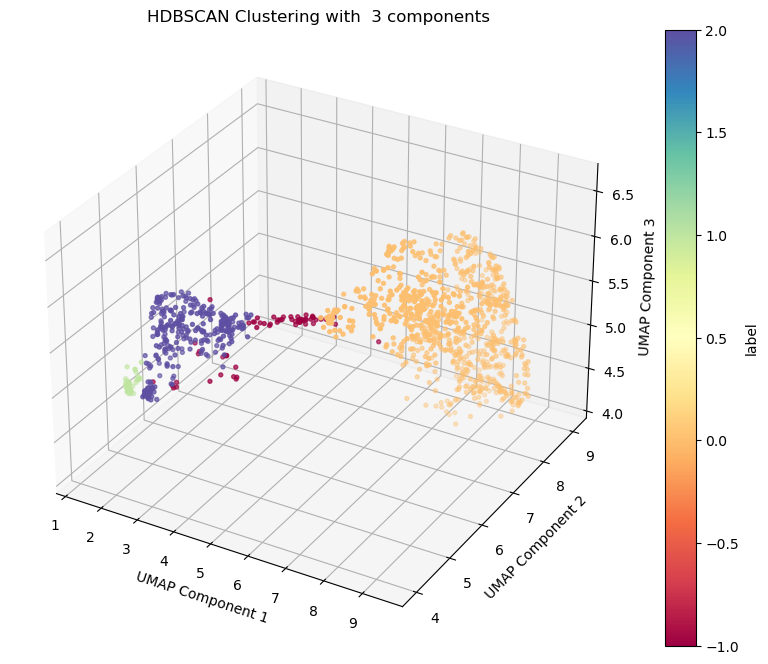

[-1  0  1  2]
Number of Noise Points: 69


In [52]:
# Assuming DataFrame df obtained the UMAP embedding with 3 components
umap_model_3d = umap.UMAP(n_components=3,min_dist=0.0,n_neighbors=50,metric='euclidean',random_state=42)
umap_embedding_3d = umap_model_3d.fit_transform(df_scaled)

# HDBSCAN clustering with adjusted parameters
labels_3d = hdbscan.HDBSCAN(
    min_samples=23,
    min_cluster_size=35,
    #metric='euclidean',
    #cluster_selection_epsilon=0.4,
    #cluster_selection_method='eom'
).fit_predict(umap_embedding_3d)

# Visualize the results in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with thicker points
scatter=ax.scatter(umap_embedding_3d[:, 0], umap_embedding_3d[:, 1], umap_embedding_3d[:, 2], c=labels_3d, s=8, cmap='Spectral')
plt.colorbar(scatter, label='label')
ax.set_xlabel('UMAP Component 1')
ax.set_ylabel('UMAP Component 2')
ax.set_zlabel('UMAP Component 3')
ax.set_title('HDBSCAN Clustering with  3 components')

plt.show()
print(np.unique(labels_3d))
num_noise_points = np.sum(labels_3d == -1)
print(f"Number of Noise Points: {num_noise_points}")

In [53]:
df_labels=pd.DataFrame()
#df_labels= pd.read_pickle('../full_seq_cluster_labels.pkl')
df_labels['UniProtID']= dF['UniProtID']
df_labels['umap_1']=(umap_embedding_3d[:,0])
df_labels['umap_2']=(umap_embedding_3d[:,1])
df_labels['umap_3']=(umap_embedding_3d[:,2])
df_labels= pd.concat([df_labels, pd.Series(labels_3d, name='Cluster Labels')], axis=1)
df_labels.to_pickle('../../eduardo/full_seq_cluster_labels.pkl')
df_labels

,UniProtID,umap_1,umap_2,umap_3,Cluster Labels
0,Q9H8Y5,7.220599,5.746816,6.057554,0
1,O60678,7.412660,8.987429,5.274909,0
2,Q96JM3,7.959334,6.979626,5.664811,0
3,Q86YF9,7.031372,8.106087,4.918390,0
4,Q9Y468,7.666933,7.048610,6.319375,0
...,...,...,...,...,...
1259,Q86UP8,7.485603,8.898280,5.317797,0
1260,Q6EKJ0,7.436213,8.937645,5.307298,0
1261,Q5VZF2,8.957880,8.219587,4.503597,0
1262,Q9HAK2,8.377962,8.619247,5.045335,0


# HDBSCAN COMPUTATIONS

In [ ]:
#Adjustable rand score and mutual info 

features = df_scaled
true_labels = dF['Numbering']

def perform_umap_hdbscan(components, features):
    umap = UMAP(n_components=components,n_neighbors=50, min_dist=0.0,metric='euclidean',random_state=42)
    umap_result = umap.fit_transform(features)
    
    hdbscan_clusterer = hdbscan.HDBSCAN(min_samples=7,min_cluster_size=40,cluster_selection_epsilon=0.1,cluster_selection_method='eom')
    hdbscan_labels = hdbscan_clusterer.fit_predict(umap_result)
    
    return hdbscan_labels

components_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for components in components_list:
    umap_hdbscan_labels = perform_umap_hdbscan(components, features)
    
    adjusted_rand = adjusted_rand_score(true_labels, umap_hdbscan_labels)
    adjusted_mutual_info = adjusted_mutual_info_score(true_labels, umap_hdbscan_labels)
    #noise percentage
    noise_percentage = np.sum(hdbscan_labels == -1) / len(hdbscan_labels)

    
    print(f"UMAP Components: {components}, Adjusted Rand Score: {adjusted_rand}, Adjusted Mutual Info Score: {adjusted_mutual_info}, Noise Percentage: {noise_percentage}")


check the noise points

In [ ]:
#noise pionts in 2d plot with 2 umap components
plt.figure(figsize=(10, 8))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=hdbscan_labels, cmap='viridis', s=10)
plt.title('HDBSCAN Clustering Results (UMAP components: 4)')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

num_noise_points = np.sum(hdbscan_labels == -1)

print(f"Number of Noise Points: {num_noise_points}")

In [ ]:
#3D plot with 3 UMAP-components
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with UMAP components 
ax.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], umap_embeddings[:, 2], c=hdbscan_labels, cmap='viridis', s=10)


ax.set_xlabel('UMAP Component 1')
ax.set_ylabel('UMAP Component 2')
ax.set_zlabel('UMAP Component 3')


ax.set_title('HDBSCAN Clustering Results (UMAP components: 4)')

plt.show()

#print no.of noise points

num_noise_points = np.sum(hdbscan_labels == -1)

print(f"Number of Noise Points: {num_noise_points}")

# K-Means clustering using umap-4 components 

In [ ]:
#visualize clustering
#visualize the clusters

#assume empty list to store intertia values
inertia=[]
for k in range(1,11):
   #test no.of clusters
   kmeans = KMeans(n_clusters = k, n_init='auto')

   #fit the model
   kmeans.fit(umap_embeddings)
    
    #append intertia for each k
   inertia.append(kmeans.inertia_)

#cluster's label and centroid
cluster_labels = kmeans.labels_
cluster_centers = kmeans.cluster_centers_

In [ ]:
#plotting elbow curve
plt.plot(range(1,11),inertia,marker='o')
plt.xlabel("K value")
plt.ylabel("Inertia")
#plt.title("The Elbow Method using Inertia")
plt.title("Finding an optimum value of K in k-means clustering")
plt.xticks(range(2,k+1))
plt.grid(True)
plt.show()

7 clusters seems to be feasible - because at 7 , we can observe the d/df=0(differentiation)


In [ ]:
#visualize the 2d figure with 7 clusters

#kmeans model with 10 clusters
model = KMeans(n_clusters=7,init='k-means++',n_init='auto')

#labeling by colouring clusters
label=model.fit_predict(umap_embeddings)

#define centriods to clusters
centers = np.array(model.cluster_centers_)

#scatter plot with specific size
plt.figure(figsize = (7,7))

uniq = np.unique(label)

#for loop iterate through each each unique cluster label 

for i in uniq:

#plot data points corresponding to each cluster label 
 plt.scatter(umap_embeddings[label == i,0 ],umap_embeddings[label == i,1 ],label=i)
#plot centroids stored in centers with marking as 'x' in black
plt.scatter(centers[:,0],centers[:,1],marker='x',color='black',label = 'Centroids')
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend()
plt.show()

In [ ]:
# Visualize in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for each cluster
for cluster in range(7):
    ax.scatter(umap_embeddings[label == cluster, 0],
               umap_embeddings[label == cluster, 1],
               umap_embeddings[label == cluster, 2],
               label=f'Cluster {cluster}',s=20)

# Plot centroids
ax.scatter(kmeans.cluster_centers_[:, 0],
           kmeans.cluster_centers_[:, 1],
           kmeans.cluster_centers_[:, 2],
           marker='x', color='black', s=100, label='Centroids')

ax.set_xlabel('UMAP Component 1')
ax.set_ylabel('UMAP Component 2')
ax.set_zlabel('UMAP Component 3')
ax.set_title('KMeans Clustering in 3D')
ax.legend()

plt.show()

In [ ]:
#silhouette score for kmeans-clustering - umap components 

silhouette_scores = []
for k in range (2,11):
    kmeans = KMeans(n_clusters = k , init = 'k-means++', random_state=42, n_init='auto')
    kmeans.fit(umap_embeddings)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(umap_embeddings,cluster_labels)
    silhouette_scores.append(silhouette_avg)
    
#visulaize silhouette scores through plotting
plt.plot(range(2,k+1),silhouette_scores,marker='o')
plt.xlabel("No.of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2,k+1))
plt.grid(True)

plt.title("Silhouette Score per No.of Clusters")

In [ ]:
df.head()